# ARC-AGI Human Solution Event Analysis

Exploring the 736-task dataset of human problem-solving traces on ARC-AGI 2.

In [1]:
import json
from collections import Counter, defaultdict
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.rcParams.update({
    'figure.facecolor': '#1e1e2e',
    'axes.facecolor': '#1e1e2e',
    'axes.edgecolor': '#cdd6f4',
    'axes.labelcolor': '#cdd6f4',
    'text.color': '#cdd6f4',
    'xtick.color': '#cdd6f4',
    'ytick.color': '#cdd6f4',
    'legend.facecolor': '#313244',
    'legend.edgecolor': '#585b70',
    'legend.labelcolor': '#cdd6f4',
    'figure.figsize': (12, 5),
})

DATA = Path('../arc-tasks-dataset.jsonl')

## 1. Load and count the full dataset

In [2]:
def load_tasks(path):
    tasks = []
    with open(path) as f:
        for i, line in enumerate(f):
            task = json.loads(line)
            tasks.append(task)
    return tasks

tasks = load_tasks(DATA)
print(f"Loaded {len(tasks)} tasks")

Loaded 1019 tasks


In [3]:
# Flatten events into a DataFrame
rows = []
for task in tasks:
    tid = task['task_id']
    for u in task.get('users', []):
        for a in u.get('attempts', []):
            aid = a['attempt_id']
            for e in a.get('events', []):
                t = e['trigger']
                rows.append({
                    'task_id': tid,
                    'user_id': u['user_id'],
                    'attempt_id': aid,
                    'event_id': e['id'],
                    'node_id': e['node_id'],
                    'kind': t.get('kind'),
                    'intent': t.get('intent'),
                    'action': t.get('action'),
                    'text': t.get('text', ''),
                    'timestamp': e['timestamp'],
                    'seq_index': e['sequence_index'],
                    'test_pair_index': e.get('test_pair_index'),
                })

df = pd.DataFrame(rows)
print(f"{len(df)} events from {df['attempt_id'].nunique()} attempts over {df['task_id'].nunique()} tasks")

35331 events from 1521 attempts over 1019 tasks


## 2. Full Event Breakdown

Each event has a `trigger` with two possible `kind` values — **mechanical** (UI actions) and **cognitive** (thinking steps).

### Mechanical actions
| action | description |
|---|---|
| `fill_selected` | Fill selected area with a color |
| `cell_paint` | Paint individual cell |
| `submit` | Submit attempt for evaluation |
| `paste_selection` | Paste copied/cut selection |
| `select_area` | Select a rectangular region |
| `load_task` | Load a task |
| `select_object` | Select a connected object (flood fill) |
| `copy_from_input` | Copy from the input grid |
| `move_selection` | Move selection to new position |
| `resize` | Resize the output grid |
| `copy_selection` | Copy selection |
| `rotate_selection` | Rotate selection |
| `cut_selection` | Cut selection |
| `reset_output` | Reset output grid to blank |
| `continue_later` | Save and continue later |
| `give_up` | Give up on the task |

### Cognitive intents
| intent | description |
|---|---|
| `initial_hypothesis` | First hypothesis when starting a task |
| `hypothesis` | A candidate transformation rule |
| `hypothesis_revision` | Revising or refining a hypothesis |
| ↳ `revisionType` | Sub-classifies the revision: `confirmed` (65.7%), `uncertain` (21.4%), `refined` (12.4%), `invalidated` (0.5%) |
| `hypothesis_finalized` | Finalizing a hypothesis as ready |
| `correct_analysis` | Analyzing why something was correct |
| `branch_pivot` | Pivoting to a different approach |

In [4]:
# Define cog for later use
cog = df[df['kind'] == 'cognitive'].copy()

# --- Event kind/intent/action breakdown ---
from collections import Counter

print("=" * 65)
print("EVENT TYPE BREAKDOWN")
print("=" * 65)

print("\n1. All (kind, intent, action) combos:")
combo = df.groupby(['kind', 'intent', 'action'], dropna=False).size().reset_index(name='count')
combo = combo.sort_values('count', ascending=False).reset_index(drop=True)
for _, row in combo.iterrows():
    k = row['kind']
    it = row['intent'] if pd.notna(row['intent']) else '-'
    ac = row['action'] if pd.notna(row['action']) else '-'
    print(f"  kind={k:12s}  intent={it:22s}  action={ac:20s}  count={row['count']:>5}")

print("\n2. Details keys (across all trigger.details dicts):")
dk = Counter()
with open(DATA) as f:
    for line in f:
        task = json.loads(line)
        for u in task.get('users', []):
            for a in u.get('attempts', []):
                for e in a.get('events', []):
                    d = e['trigger'].get('details', {})
                    for k in d:
                        dk[k] += 1
for k, v in dk.most_common():
    print(f"  {k}: {v}")

print("\n3. Node ID prefixes:")
node_prefixes = df['node_id'].str.extract(r'^(.*?)_\\d+$', expand=False)
node_prefixes = node_prefixes.fillna(df['node_id'])
print(node_prefixes.value_counts().to_string())

print("\n4. test_pair_index distribution:")
tpi = df.groupby('test_pair_index').size()
print(tpi.to_string())

print("\n5. Cognitive intent × test_pair_index:")
cog_tpi = cog.groupby(['intent', 'test_pair_index']).size().unstack(fill_value=0)
print(cog_tpi.to_string())

EVENT TYPE BREAKDOWN

1. All (kind, intent, action) combos:
  kind=mechanical    intent=-                       action=fill_selected         count= 6486
  kind=cognitive     intent=hypothesis_revision     action=-                     count= 5161
  kind=mechanical    intent=-                       action=cell_paint            count= 3516
  kind=mechanical    intent=-                       action=submit                count= 2664
  kind=mechanical    intent=-                       action=select_area           count= 2132
  kind=mechanical    intent=-                       action=paste_selection       count= 1966
  kind=mechanical    intent=-                       action=load_task             count= 1674
  kind=cognitive     intent=hypothesis              action=-                     count= 1670
  kind=cognitive     intent=hypothesis_finalized    action=-                     count= 1459
  kind=cognitive     intent=initial_hypothesis      action=-                     count= 1453
  kind=mec

## 3. Event Totals & Overview

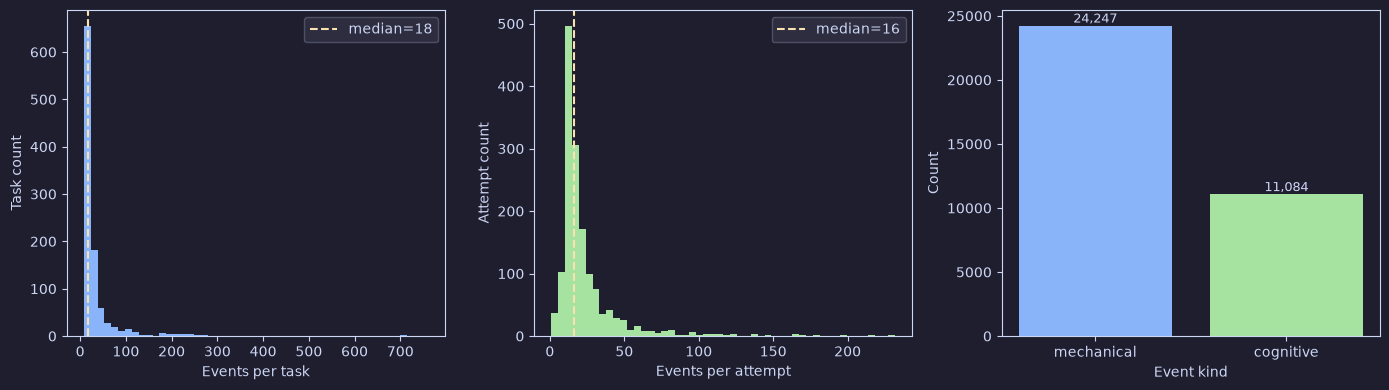

Total events: 35,331
  Mechanical: 24,247
  Cognitive:  11,084


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# (a) Events per task
events_per_task = df.groupby('task_id').size()
axes[0].hist(events_per_task, bins=50, color='#89b4fa', edgecolor='none')
axes[0].set_xlabel('Events per task')
axes[0].set_ylabel('Task count')
axes[0].axvline(events_per_task.median(), color='#f9e2af', ls='--', label=f"median={events_per_task.median():.0f}")
axes[0].legend()

# (b) Events per attempt
events_per_attempt = df.groupby('attempt_id').size()
axes[1].hist(events_per_attempt, bins=50, color='#a6e3a1', edgecolor='none')
axes[1].set_xlabel('Events per attempt')
axes[1].set_ylabel('Attempt count')
axes[1].axvline(events_per_attempt.median(), color='#f9e2af', ls='--', label=f"median={events_per_attempt.median():.0f}")
axes[1].legend()

# (c) Events by kind
kind_counts = df.groupby('kind').size().sort_values(ascending=False)
colors = ['#89b4fa', '#a6e3a1', '#f38ba8', '#fab387', '#cba6f7', '#94e2d5']
bars = axes[2].bar(kind_counts.index, kind_counts.values, color=colors[:len(kind_counts)], edgecolor='none')
axes[2].set_xlabel('Event kind')
axes[2].set_ylabel('Count')
for bar, val in zip(bars, kind_counts.values):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                f'{val:,}', ha='center', va='bottom', color='#cdd6f4', fontsize=9)

plt.tight_layout()
plt.show()

print(f"Total events: {len(df):,}")
print(f"  Mechanical: {len(df[df['kind']=='mechanical']):,}")
print(f"  Cognitive:  {len(df[df['kind']=='cognitive']):,}")

## 4. Event Distributions Over the Full Dataset

Cumulative distributions, per-user breakdowns, and event timing patterns.

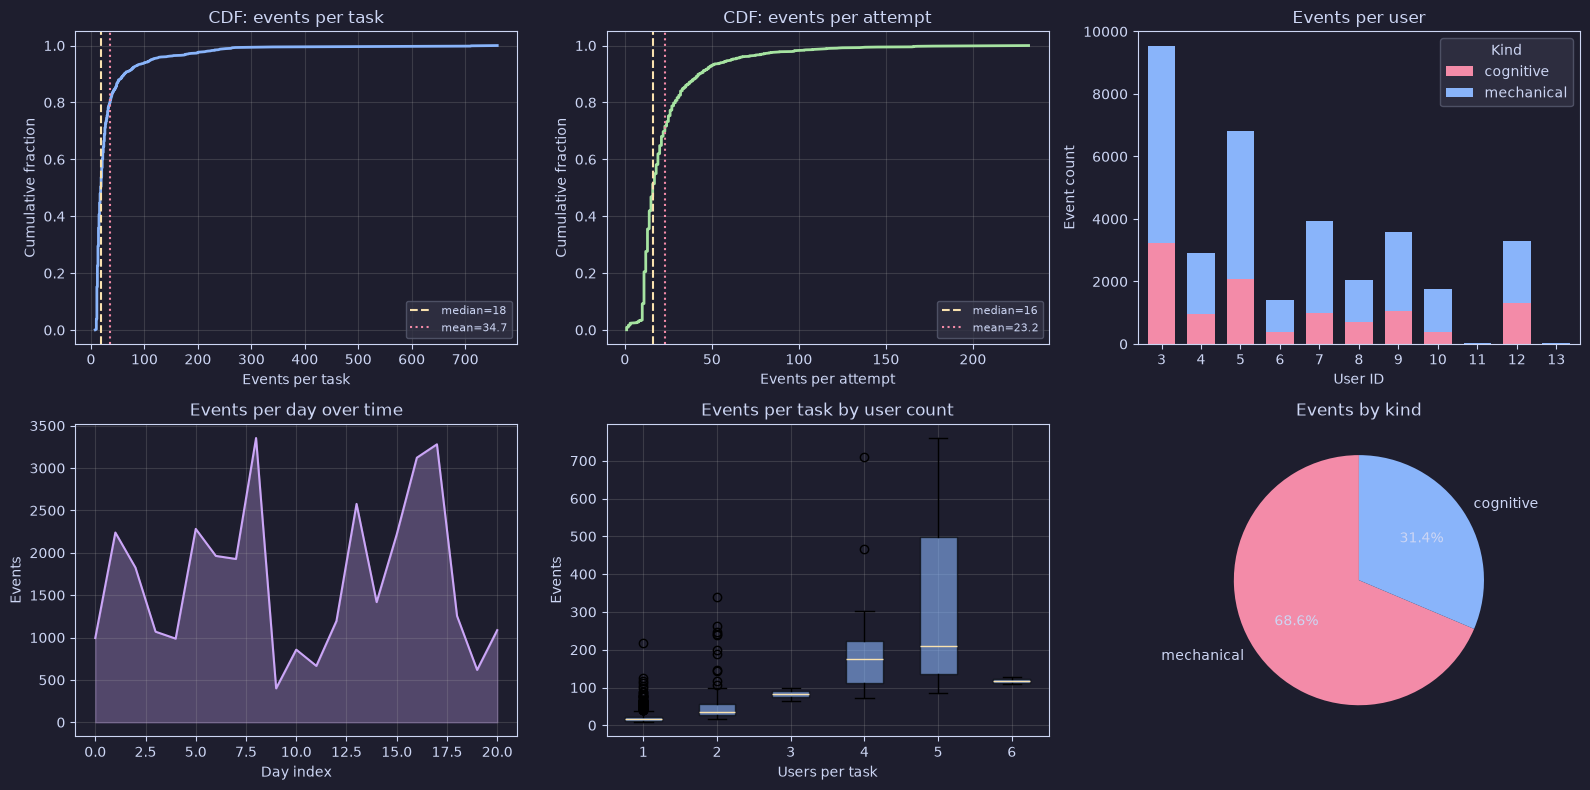

Date range: 2026-06-30 to 2026-07-20
Days with activity: 21
Events per day: mean=1682, median=1418, max=3354


[Text(1, 0, '1'),
 Text(2, 0, '2'),
 Text(3, 0, '3'),
 Text(4, 0, '7'),
 Text(5, 0, '8'),
 Text(6, 0, '9')]

In [6]:
# --- Event distributions ---
fig, axes = plt.subplots(2, 3, figsize=(16, 8))

# (a) CDF: events per task
ep_task_sorted = np.sort(events_per_task.values)
cdf = np.arange(1, len(ep_task_sorted) + 1) / len(ep_task_sorted)
axes[0, 0].plot(ep_task_sorted, cdf, color='#89b4fa', linewidth=2)
axes[0, 0].axvline(events_per_task.median(), color='#f9e2af', ls='--', label=f'median={events_per_task.median():.0f}')
axes[0, 0].axvline(events_per_task.mean(), color='#f38ba8', ls=':', label=f'mean={events_per_task.mean():.1f}')
axes[0, 0].set_xlabel('Events per task')
axes[0, 0].set_ylabel('Cumulative fraction')
axes[0, 0].set_title('CDF: events per task')
axes[0, 0].legend(fontsize=8)
axes[0, 0].grid(alpha=0.2)

# (b) CDF: events per attempt
ep_att_sorted = np.sort(events_per_attempt.values)
cdf2 = np.arange(1, len(ep_att_sorted) + 1) / len(ep_att_sorted)
axes[0, 1].plot(ep_att_sorted, cdf2, color='#a6e3a1', linewidth=2)
axes[0, 1].axvline(events_per_attempt.median(), color='#f9e2af', ls='--', label=f'median={events_per_attempt.median():.0f}')
axes[0, 1].axvline(events_per_attempt.mean(), color='#f38ba8', ls=':', label=f'mean={events_per_attempt.mean():.1f}')
axes[0, 1].set_xlabel('Events per attempt')
axes[0, 1].set_ylabel('Cumulative fraction')
axes[0, 1].set_title('CDF: events per attempt')
axes[0, 1].legend(fontsize=8)
axes[0, 1].grid(alpha=0.2)

# (c) Events per user (stacked by kind)
user_kind = df.groupby(['user_id', 'kind']).size().unstack(fill_value=0)
user_kind.plot(kind='bar', stacked=True, ax=axes[0, 2], color=['#f38ba8', '#89b4fa'], edgecolor='none', width=0.7)
axes[0, 2].set_xlabel('User ID')
axes[0, 2].set_ylabel('Event count')
axes[0, 2].set_title('Events per user')
axes[0, 2].legend(title='Kind')
axes[0, 2].tick_params(axis='x', rotation=0)

# (d) Events by day (timestamp → datetime)
df['datetime'] = pd.to_datetime(df['timestamp'], unit='ms')
df['date'] = df['datetime'].dt.date
daily = df.groupby('date').size()
axes[1, 0].plot(range(len(daily)), daily.values, color='#cba6f7', linewidth=1.5)
axes[1, 0].fill_between(range(len(daily)), daily.values, alpha=0.3, color='#cba6f7')
axes[1, 0].set_xlabel('Day index')
axes[1, 0].set_ylabel('Events')
axes[1, 0].set_title('Events per day over time')
axes[1, 0].grid(alpha=0.2)

# (e) Box plot: events per task by number of users
users_per_task_map = df.groupby('task_id')['user_id'].nunique()
task_user_groups = {}
for tid, n_users in users_per_task_map.items():
    task_user_groups.setdefault(n_users, []).append(events_per_task[tid])
labels = sorted(task_user_groups.keys())
data = [task_user_groups[lu] for lu in labels]
bp = axes[1, 1].boxplot(data, patch_artist=True,
                        boxprops=dict(facecolor='#89b4fa', alpha=0.6),
                        medianprops=dict(color='#f9e2af'))
axes[1, 1].set_xlabel('Users per task')
axes[1, 1].set_ylabel('Events')
axes[1, 1].set_title('Events per task by user count')
axes[1, 1].grid(alpha=0.2)

# (f) Pie: mechanical vs cognitive
kind_pie = df['kind'].value_counts()
axes[1, 2].pie(kind_pie.values, labels=kind_pie.index, autopct='%1.1f%%',
               colors=['#f38ba8', '#89b4fa'], startangle=90, textprops=dict(color='#cdd6f4'))
axes[1, 2].set_title('Events by kind')

plt.tight_layout()
plt.show()

print(f"Date range: {df['date'].min()} to {df['date'].max()}")
print(f"Days with activity: {daily.count()}")
print(f"Events per day: mean={daily.mean():.0f}, median={daily.median():.0f}, max={daily.max()}")
axes[1, 1].set_xticklabels(labels)


## 5. Cognitive Intent Breakdown

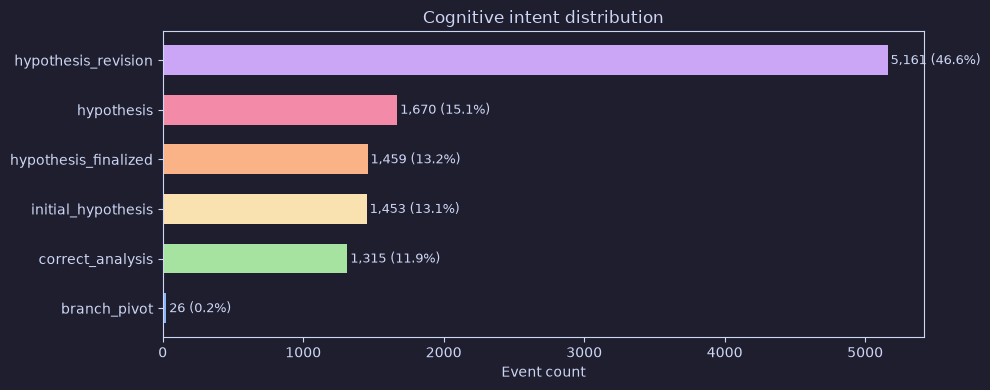

In [7]:
cog = df[df['kind'] == 'cognitive'].copy()
intent_counts = cog.groupby('intent').size().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 4))
colors = ['#89b4fa', '#a6e3a1', '#f9e2af', '#fab387', '#f38ba8', '#cba6f7', '#94e2d5']
bars = ax.barh(intent_counts.index, intent_counts.values, color=colors[:len(intent_counts)], edgecolor='none', height=0.6)
ax.set_xlabel('Event count')
ax.set_title('Cognitive intent distribution')
for bar, val in zip(bars, intent_counts.values):
    ax.text(bar.get_width() + 20, bar.get_y() + bar.get_height()/2,
            f'{val:,} ({val/len(cog)*100:.1f}%)', va='center', color='#cdd6f4', fontsize=9)
plt.tight_layout()
plt.show()

## 6. Cognitive Event Sub-Types

Cognitive events carry important sub-type information in their `details` field.

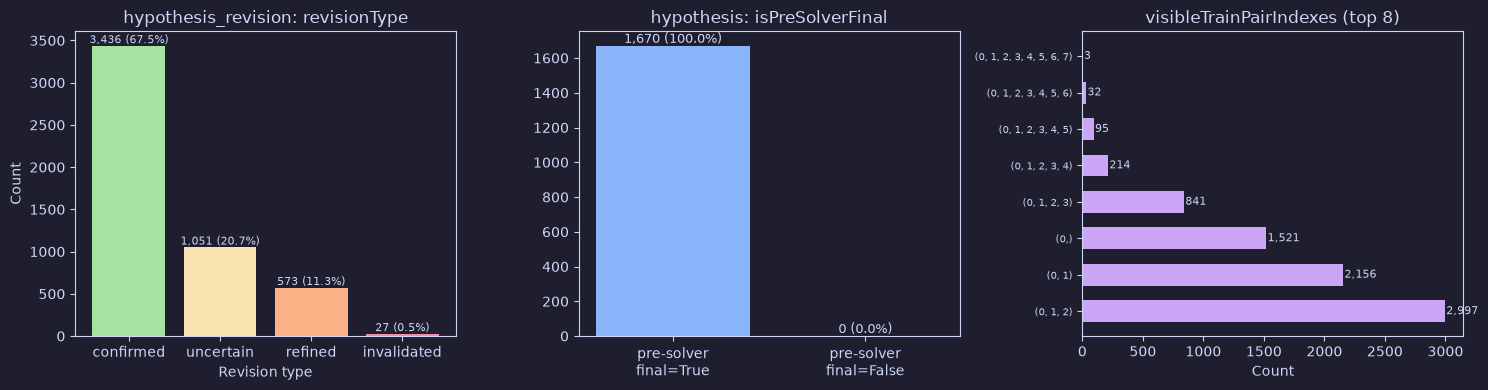


revisionType breakdown (hypothesis_revision):
  confirmed     :  3436 ( 67.5%)
  uncertain     :  1051 ( 20.7%)
  refined       :   573 ( 11.3%)
  invalidated   :    27 (  0.5%)


In [8]:
# --- Cognitive sub-type breakdown ---
from collections import Counter

# (a) revisionType distribution (from hypothesis_revision)
rev_types = Counter()
with open(DATA) as f:
    for line in f:
        task = json.loads(line)
        for u in task.get('users', []):
            for a in u.get('attempts', []):
                for e in a.get('events', []):
                    t = e['trigger']
                    rt = t.get('details', {}).get('revisionType')
                    if rt:
                        rev_types[rt] += 1

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

rt_items = sorted(rev_types.items(), key=lambda x: -x[1])
rt_labels = [k for k, _ in rt_items]
rt_vals = [v for _, v in rt_items]
colors_rt = ['#a6e3a1', '#f9e2af', '#fab387', '#f38ba8']
bars = axes[0].bar(rt_labels, rt_vals, color=colors_rt[:len(rt_labels)], edgecolor='none')
axes[0].set_xlabel('Revision type')
axes[0].set_ylabel('Count')
axes[0].set_title('hypothesis_revision: revisionType')
for bar, val in zip(bars, rt_vals):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                f'{val:,} ({val/sum(rt_vals)*100:.1f}%)',
                ha='center', va='bottom', color='#cdd6f4', fontsize=8)

# (b) isPreSolverFinal (from hypothesis events)
pre_final = Counter()
with open(DATA) as f:
    for line in f:
        task = json.loads(line)
        for u in task.get('users', []):
            for a in u.get('attempts', []):
                for e in a.get('events', []):
                    t = e['trigger']
                    if t.get('intent') == 'hypothesis':
                        val = t.get('details', {}).get('isPreSolverFinal')
                        if val is not None:
                            pre_final[val] += 1
pf_labels = ['pre-solver\nfinal=True', 'pre-solver\nfinal=False']
pf_vals = [pre_final.get(True, 0), pre_final.get(False, 0)]
bars2 = axes[1].bar(pf_labels, pf_vals, color=['#89b4fa', '#f38ba8'], edgecolor='none')
axes[1].set_title('hypothesis: isPreSolverFinal')
for bar, val in zip(bars2, pf_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                f'{val:,} ({val/sum(pf_vals)*100:.1f}%)',
                ha='center', va='bottom', color='#cdd6f4', fontsize=9)

# (c) visibleTrainPairIndexes patterns
vp = Counter()
with open(DATA) as f:
    for line in f:
        task = json.loads(line)
        for u in task.get('users', []):
            for a in u.get('attempts', []):
                for e in a.get('events', []):
                    t = e['trigger']
                    vpi = t.get('details', {}).get('visibleTrainPairIndexes')
                    if vpi is not None:
                        vp[tuple(vpi)] += 1
vp_items = sorted(vp.items(), key=lambda x: -x[1])[:8]
vp_labels = [str(k) for k, _ in vp_items]
vp_vals = [v for _, v in vp_items]
bars3 = axes[2].barh(range(len(vp_items)), vp_vals, color='#cba6f7', edgecolor='none', height=0.6)
axes[2].set_yticks(range(len(vp_items)))
axes[2].set_yticklabels(vp_labels, fontsize=7)
axes[2].set_xlabel('Count')
axes[2].set_title('visibleTrainPairIndexes (top 8)')
for bar, val in zip(bars3, vp_vals):
    axes[2].text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2,
                f'{val:,}', va='center', color='#cdd6f4', fontsize=8)

plt.tight_layout()
plt.show()

print("")
print("revisionType breakdown (hypothesis_revision):")
for k, v in sorted(rev_types.items(), key=lambda x: -x[1]):
    pct = [{}, 'confirmed', 'uncertain', 'refined', 'invalidated'].index(k) if k in ['confirmed', 'uncertain', 'refined', 'invalidated'] else 0
    print(f"  {k:14s}: {v:>5} ({v/sum(rev_types.values())*100:5.1f}%)")

## 6. Attempts per user & success patterns

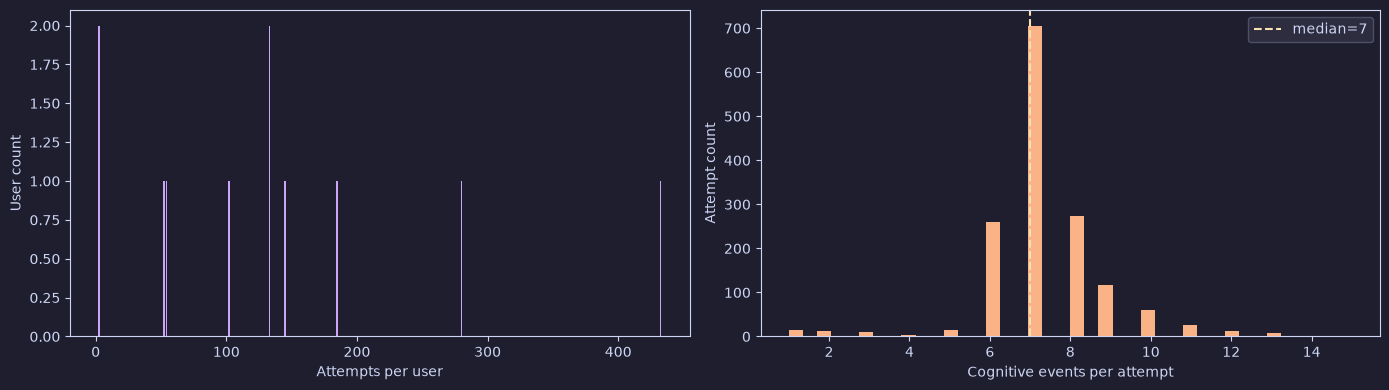

Unique users: 11
Attempts per user: mean=138.3, median=133, max=433


In [9]:
attempt_counts = df.groupby(['user_id', 'attempt_id']).size().reset_index()
user_attempts = attempt_counts.groupby('user_id')['attempt_id'].nunique()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(user_attempts, bins=user_attempts.max(), color='#cba6f7', edgecolor='none')
axes[0].set_xlabel('Attempts per user')
axes[0].set_ylabel('User count')

# Cognitive events per attempt
cog_per_attempt = cog.groupby('attempt_id').size()
axes[1].hist(cog_per_attempt, bins=40, color='#fab387', edgecolor='none')
axes[1].axvline(cog_per_attempt.median(), color='#f9e2af', ls='--', label=f"median={cog_per_attempt.median():.0f}")
axes[1].set_xlabel('Cognitive events per attempt')
axes[1].set_ylabel('Attempt count')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Unique users: {df['user_id'].nunique()}")
print(f"Attempts per user: mean={user_attempts.mean():.1f}, median={user_attempts.median():.0f}, max={user_attempts.max()}")

## 7. Hypothesis text length

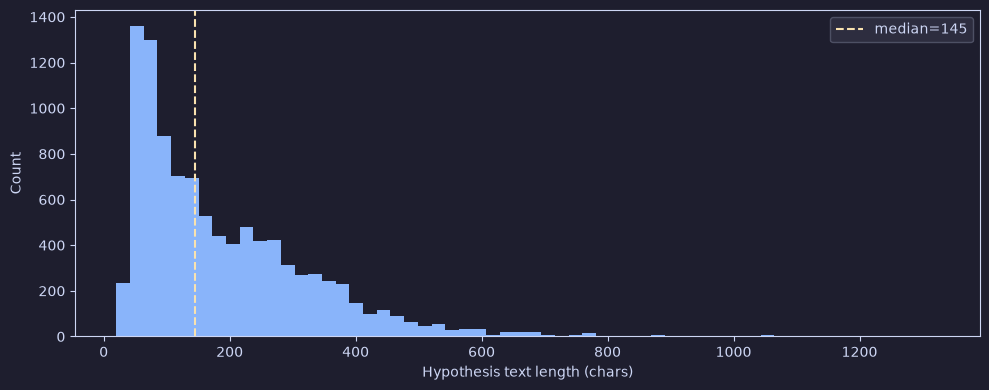

10031 / 11084 cognitive events have non-empty text (90.5%)


In [10]:
has_text = cog[cog['text'].str.len() > 0].copy()
has_text['text_len'] = has_text['text'].str.len()

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(has_text['text_len'], bins=60, color='#89b4fa', edgecolor='none')
ax.set_xlabel('Hypothesis text length (chars)')
ax.set_ylabel('Count')
ax.axvline(has_text['text_len'].median(), color='#f9e2af', ls='--', label=f"median={has_text['text_len'].median():.0f}")
ax.legend()
plt.tight_layout()
plt.show()

print(f"{len(has_text)} / {len(cog)} cognitive events have non-empty text ({len(has_text)/len(cog)*100:.1f}%)")

## 8. Events over time (by sequence index)

How many cognitive vs mechanical events occur at each step of an attempt?

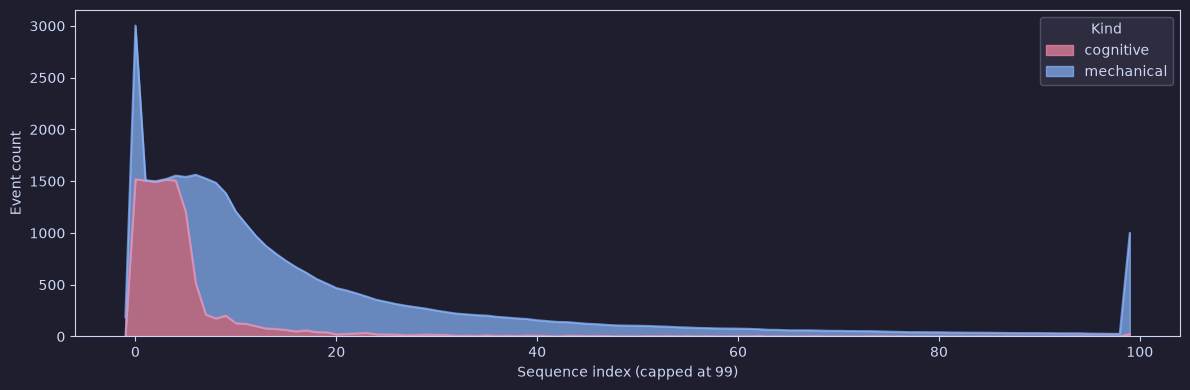

In [11]:
# Cap at 99 for readability
seq = df.copy()
seq['seq_bin'] = seq['seq_index'].clip(upper=99)

pivot = seq.groupby(['seq_bin', 'kind']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(12, 4))
pivot.plot(kind='area', ax=ax, color=['#f38ba8', '#89b4fa'], alpha=0.7)
ax.set_xlabel('Sequence index (capped at 99)')
ax.set_ylabel('Event count')
ax.legend(title='Kind')
plt.tight_layout()
plt.show()

## 9. Unique users per task

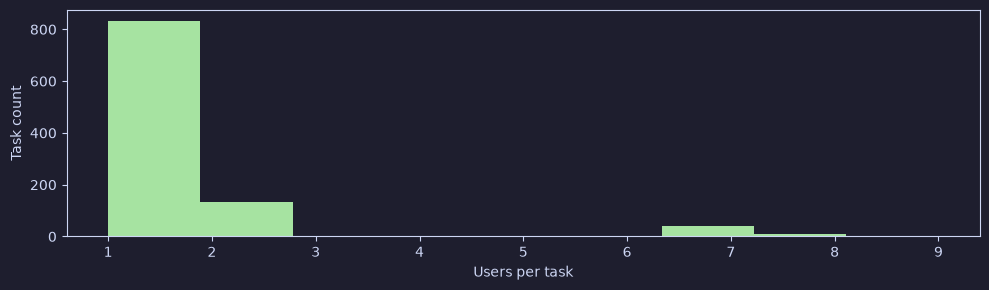

Users per task: min=1, median=1, max=9


In [12]:
users_per_task = df.groupby('task_id')['user_id'].nunique()

fig, ax = plt.subplots(figsize=(10, 3))
ax.hist(users_per_task, bins=users_per_task.max(), color='#a6e3a1', edgecolor='none')
ax.set_xlabel('Users per task')
ax.set_ylabel('Task count')
plt.tight_layout()
plt.show()

print(f"Users per task: min={users_per_task.min()}, median={users_per_task.median():.0f}, max={users_per_task.max()}")

## 10. Summary statistics

In [13]:
print("=" * 50)
print("DATASET SUMMARY")
print("=" * 50)
print(f"  Tasks:                    {len(tasks):,}")
print(f"  Unique users:            {df['user_id'].nunique():,}")
print(f"  Total attempts:          {df['attempt_id'].nunique():,}")
print(f"  Total events:            {len(df):,}")
print(f"    Mechanical:            {len(df[df['kind']=='mechanical']):,}")
print(f"    Cognitive:             {len(df[df['kind']=='cognitive']):,}")
print()
print("Per task:")
print(f"  Users (median):          {users_per_task.median():.0f}")
print(f"  Events (median):         {events_per_task.median():.0f}")
print()
print("Per attempt:")
print(f"  Events (median):         {events_per_attempt.median():.0f}")
print(f"  Cognitive events (median): {cog_per_attempt.median():.0f}")

DATASET SUMMARY
  Tasks:                    1,019
  Unique users:            11
  Total attempts:          1,521
  Total events:            35,331
    Mechanical:            24,247
    Cognitive:             11,084

Per task:
  Users (median):          1
  Events (median):         18

Per attempt:
  Events (median):         16
  Cognitive events (median): 7


## 11. Sample hypothesis texts

In [14]:
samples = has_text.groupby('intent').apply(lambda x: x.sample(2, random_state=42))
for (intent, _), row in samples.iterrows():
    print(f"\n[{intent}] task={row['task_id'][:8]}... | attempt={row['attempt_id']}")
    print(f"  {row['text'][:300]}")


[branch_pivot] task=46c35fc7... | attempt=121
  Todas las esquinas se rotan en sentido antihorario, y las celdas del medio se rotan en centido horario 90 grados

[branch_pivot] task=9aaea919... | attempt=381
  Si una columna de figuras tiene en su base una línea horizontal roja, dichas figuras se pintan de gris. En cambio si en su base hay una línea horizontal verde, se copian por arriba las figuras de la columna a su derecha, pintadas del mismo color que las figuras originales en la columna de base verde

[correct_analysis] task=2c181942... | attempt=747
  Hay un cuadrado celeste con 4 colores en sus lados. Tambien hay otras figuras de colores que hay que rotarlas y hacerlas encajar en el cuadrado celeste.

[correct_analysis] task=e21a174a... | attempt=1453
  Enumero las figuras de colores, siendo la de mas arriba la 1 y la ultima n. Intercambio la posicion 1 con la n, la 2 con la figura n-1 y asi hasta no se puedan intercambiar mas.

[hypothesis] task=575b1a71... | attempt=779
  La 